# 07 — Deep Research: What Drives Faster Resolution, Where Money Is Lost, How to Save Beds

Independent, unbiased analysis of kidney stone (N20) data.

**Research questions:**
1. What determines faster kidney stone resolution (shorter LOS)?
2. Where exactly is money being lost?
3. How many beds can realistically be saved, and how?

This notebook does NOT rely on the previous ML model (R²=0.096). Instead it uses direct data analysis,
stratified comparisons, and empirical distributions to draw conclusions.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from scipy import stats
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

OUTPUT_DIR = Path("../outputs")
PLOT_DIR = OUTPUT_DIR / "plots"
METRICS_DIR = OUTPUT_DIR / "metrics"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

kidney = pd.read_parquet(OUTPUT_DIR / "kidney_sih.parquet")
print(f"Records loaded: {len(kidney):,}")
print(f"Year range: {kidney['year'].min()} - {kidney['year'].max()}")
print(f"Columns: {list(kidney.columns)}")

Records loaded: 206,500
Year range: 2015 - 2025
Columns: ['DIAG_PRINC', 'DIAG_SECUN', 'PROC_REA', 'PROC_SOLIC', 'DIAS_PERM', 'MUNIC_RES', 'MUNIC_MOV', 'CAR_INT', 'ESPEC', 'CNES', 'IDADE', 'COD_IDADE', 'SEXO', 'VAL_TOT', 'MORTE', 'DT_INTER', 'DT_SAIDA', 'MARCA_UTI', 'COMPLEX', 'NATUREZA', 'UF_ZI', 'year', 'month']


In [2]:
# Prepare derived columns (strings in SIH data — must cast explicitly)
kidney["PROC_REA"] = kidney["PROC_REA"].astype(str).str.strip()
kidney["is_emergency"] = (kidney["CAR_INT"].astype(str) == "02").astype(int)
kidney["is_male"] = (kidney["SEXO"].astype(str) == "1").astype(int)
kidney["migrated"] = kidney["MUNIC_RES"].astype(str) != kidney["MUNIC_MOV"].astype(str)
kidney["age"] = pd.to_numeric(kidney["IDADE"], errors="coerce").fillna(0)
kidney["MORTE"] = pd.to_numeric(kidney["MORTE"], errors="coerce").fillna(0).astype(int)
kidney["DIAS_PERM"] = pd.to_numeric(kidney["DIAS_PERM"], errors="coerce").fillna(0)
kidney["VAL_TOT"] = pd.to_numeric(kidney["VAL_TOT"], errors="coerce").fillna(0)

NEW_PROC = "0409010596"  # Transureteroscopic Ureterolithotripsy
LITHO_PROC = "0409010146"  # Extracorporeal Lithotripsy
PERC_PROC = "0409010073"  # Percutaneous Nephrolithotomy
OPEN_PROC = "0409010030"  # Open/Laparoscopic

PROC_LABELS = {
    NEW_PROC: "Ureteroscopy (modern)",
    LITHO_PROC: "Ext. Lithotripsy",
    PERC_PROC: "Percutaneous",
    OPEN_PROC: "Open/Lap",
}

kidney["proc_label"] = kidney["PROC_REA"].map(PROC_LABELS).fillna("Other/Conservative")
kidney["bed_days_cost"] = kidney["VAL_TOT"]

print(f"\nProcedure distribution:")
print(kidney["proc_label"].value_counts())
print(f"\nAdmission type: Emergency={kidney['is_emergency'].mean()*100:.1f}%")
print(f"Migration rate: {kidney['migrated'].mean()*100:.1f}%")
print(f"Male: {kidney['is_male'].mean()*100:.1f}%")


Procedure distribution:
proc_label
Other/Conservative       169680
Ureteroscopy (modern)     34036
Ext. Lithotripsy           2784
Name: count, dtype: int64

Admission type: Emergency=56.5%
Migration rate: 36.5%
Male: 47.2%


## Part 1: Where Is Money Being Lost?

Analyze total cost by: procedure type, admission type, hospital, city, year.
Identify the biggest cost drivers and waste pockets.

In [3]:
# Total spend overview
total_cost = kidney["bed_days_cost"].sum()
total_bed_days = kidney["DIAS_PERM"].sum()
total_admissions = len(kidney)

print(f"=== Kidney Stone (N20) Financial Overview ===")
print(f"Total admissions: {total_admissions:,}")
print(f"Total bed-days: {total_bed_days:,.0f}")
print(f"Total cost: R$ {total_cost:,.0f}")
print(f"Avg cost/admission: R$ {total_cost/total_admissions:,.0f}")
print(f"Avg cost/bed-day: R$ {total_cost/total_bed_days:,.0f}")
print(f"Avg LOS: {kidney['DIAS_PERM'].mean():.2f} days (median: {kidney['DIAS_PERM'].median():.0f})")

=== Kidney Stone (N20) Financial Overview ===
Total admissions: 206,500
Total bed-days: 507,465
Total cost: R$ 187,823,156
Avg cost/admission: R$ 910
Avg cost/bed-day: R$ 370
Avg LOS: 2.46 days (median: 2)


In [4]:
# Cost by procedure type
cost_by_proc = kidney.groupby("proc_label").agg(
    n_admissions=("DIAG_PRINC", "count"),
    total_cost=("bed_days_cost", "sum"),
    avg_cost=("bed_days_cost", "mean"),
    total_bed_days=("DIAS_PERM", "sum"),
    avg_los=("DIAS_PERM", "mean"),
    median_los=("DIAS_PERM", "median"),
    pct_emergency=("is_emergency", "mean"),
    mortality=("MORTE", "mean"),
).sort_values("total_cost", ascending=False)

cost_by_proc["pct_of_total_cost"] = cost_by_proc["total_cost"] / total_cost * 100
cost_by_proc["pct_of_total_bed_days"] = cost_by_proc["total_bed_days"] / total_bed_days * 100
cost_by_proc["cost_per_bed_day"] = cost_by_proc["total_cost"] / cost_by_proc["total_bed_days"]

print("=== Cost by Procedure Type ===")
display_cols = ["n_admissions", "avg_los", "median_los", "avg_cost", "pct_of_total_cost",
                "pct_of_total_bed_days", "cost_per_bed_day", "pct_emergency", "mortality"]
print(cost_by_proc[display_cols].round(2).to_string())

=== Cost by Procedure Type ===
                       n_admissions  avg_los  median_los  avg_cost  pct_of_total_cost  pct_of_total_bed_days  cost_per_bed_day  pct_emergency  mortality
proc_label                                                                                                                                              
Other/Conservative           169680     2.60         2.0    857.73              77.49                  87.04            329.49           0.62        0.0
Ureteroscopy (modern)         34036     1.86         1.0   1187.69              21.52                  12.46            639.10           0.35        0.0
Ext. Lithotripsy               2784     0.90         0.0    668.13               0.99                   0.49            743.44           0.18        0.0


In [5]:
# Cost by admission type (Emergency vs Elective)
adm_labels = {1: "Emergency", 0: "Elective"}
cost_by_adm = kidney.groupby("is_emergency").agg(
    n_admissions=("DIAG_PRINC", "count"),
    total_cost=("bed_days_cost", "sum"),
    avg_cost=("bed_days_cost", "mean"),
    total_bed_days=("DIAS_PERM", "sum"),
    avg_los=("DIAS_PERM", "mean"),
    median_los=("DIAS_PERM", "median"),
    mortality=("MORTE", "mean"),
)
cost_by_adm.index = cost_by_adm.index.map(adm_labels)
cost_by_adm["excess_cost_vs_elective"] = 0.0

if "Elective" in cost_by_adm.index and "Emergency" in cost_by_adm.index:
    elective_avg = cost_by_adm.loc["Elective", "avg_cost"]
    emergency_n = cost_by_adm.loc["Emergency", "n_admissions"]
    emergency_avg = cost_by_adm.loc["Emergency", "avg_cost"]
    excess = (emergency_avg - elective_avg) * emergency_n
    cost_by_adm.loc["Emergency", "excess_cost_vs_elective"] = excess

print("=== Cost by Admission Type ===")
print(cost_by_adm.round(2).to_string())
print(f"\nExcess cost of emergency vs elective: R$ {excess:,.0f}")
print(f"Emergency avg LOS: {cost_by_adm.loc['Emergency', 'avg_los']:.2f} days")
print(f"Elective avg LOS: {cost_by_adm.loc['Elective', 'avg_los']:.2f} days")
print(f"LOS gap: {cost_by_adm.loc['Emergency', 'avg_los'] - cost_by_adm.loc['Elective', 'avg_los']:.2f} days")

=== Cost by Admission Type ===
              n_admissions   total_cost  avg_cost  total_bed_days  avg_los  median_los  mortality  excess_cost_vs_elective
is_emergency                                                                                                              
Elective             89828  96168144.67   1070.58          159448     1.78         1.0       0.00                     0.00
Emergency           116672  91655010.88    785.58          348017     2.98         2.0       0.01             -33251808.54

Excess cost of emergency vs elective: R$ -33,251,809
Emergency avg LOS: 2.98 days
Elective avg LOS: 1.78 days
LOS gap: 1.21 days


=== Procedure x Admission Type (avg LOS, avg cost) ===
                                         n  avg_los  avg_cost  total_bed_days
proc_label            is_emergency                                           
Ext. Lithotripsy      0               2271     0.39    673.71             876
                      1                513     3.17    643.42            1626
Other/Conservative    0              65295     1.96   1034.46          127913
                      1             104385     3.01    747.18          313798
Ureteroscopy (modern) 0              22262     1.38   1217.02           30659
                      1              11774     2.77   1132.23           32593


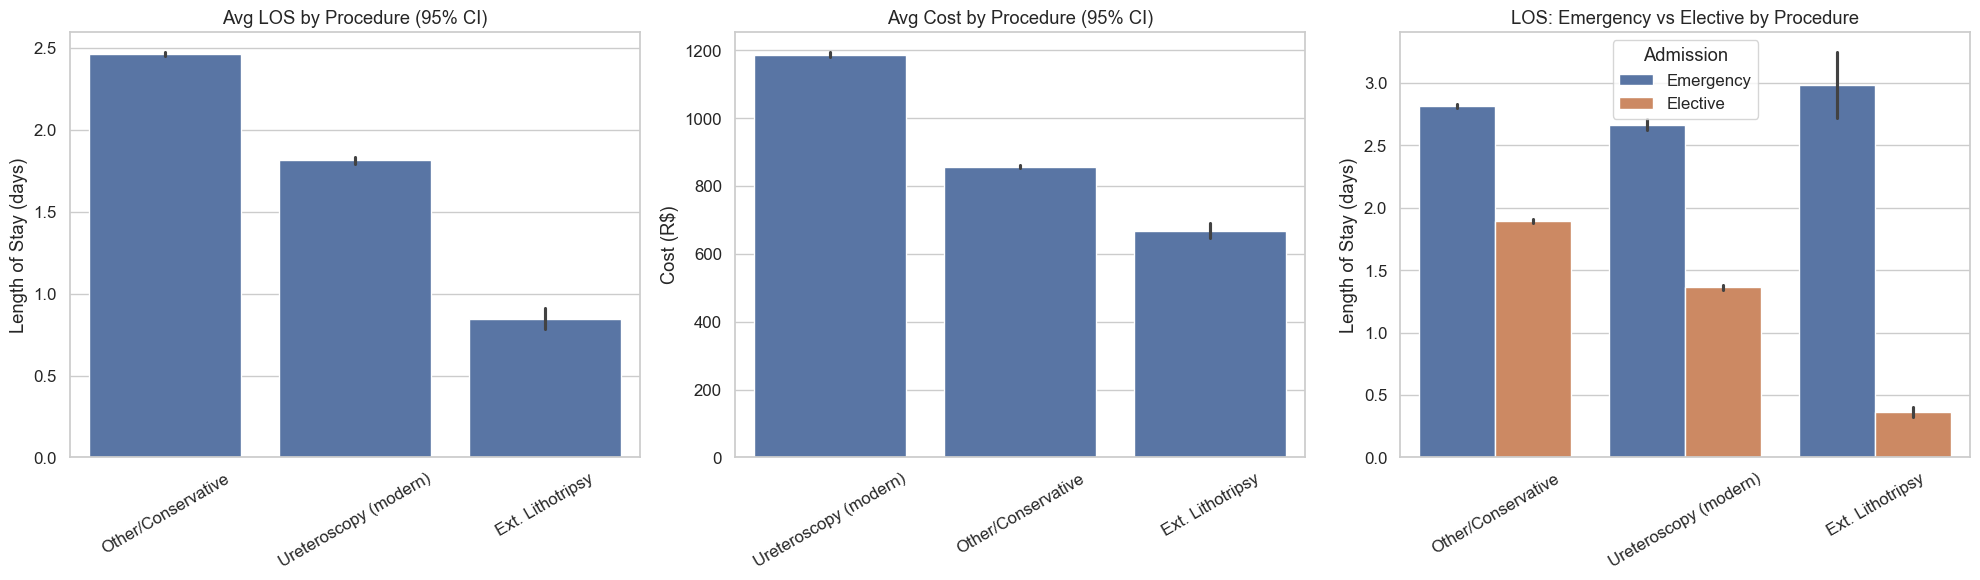

In [6]:
# Cross-tabulation: Procedure x Admission Type
cross = kidney.groupby(["proc_label", "is_emergency"]).agg(
    n=("DIAG_PRINC", "count"),
    avg_los=("DIAS_PERM", "mean"),
    avg_cost=("bed_days_cost", "mean"),
    total_bed_days=("DIAS_PERM", "sum"),
).round(2)

print("=== Procedure x Admission Type (avg LOS, avg cost) ===")
print(cross.to_string())

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# LOS by procedure
proc_order = cost_by_proc.sort_values("avg_los", ascending=False).index
sns.barplot(data=kidney[kidney["DIAS_PERM"] <= 20], x="proc_label", y="DIAS_PERM",
            order=proc_order, ax=axes[0], errorbar="ci")
axes[0].set_title("Avg LOS by Procedure (95% CI)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_xlabel("")
axes[0].set_ylabel("Length of Stay (days)")

# Cost by procedure
proc_cost_order = cost_by_proc.sort_values("avg_cost", ascending=False).index
sns.barplot(data=kidney, x="proc_label", y="bed_days_cost",
            order=proc_cost_order, ax=axes[1], errorbar="ci")
axes[1].set_title("Avg Cost by Procedure (95% CI)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_xlabel("")
axes[1].set_ylabel("Cost (R$)")

# LOS: Emergency vs Elective by procedure
kidney["adm_label"] = kidney["is_emergency"].map({1: "Emergency", 0: "Elective"})
sns.barplot(data=kidney[kidney["DIAS_PERM"] <= 20], x="proc_label", y="DIAS_PERM",
            hue="adm_label", order=proc_order, ax=axes[2], errorbar="ci")
axes[2].set_title("LOS: Emergency vs Elective by Procedure")
axes[2].tick_params(axis="x", rotation=30)
axes[2].set_xlabel("")
axes[2].set_ylabel("Length of Stay (days)")
axes[2].legend(title="Admission")

plt.tight_layout()
plt.savefig(PLOT_DIR / "07_cost_by_procedure.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 2: What Determines Faster Resolution?

Stratified analysis — not ML, but direct empirical comparisons with confidence intervals.
The goal: identify which factors actually move the needle on LOS.

In [7]:
# Factor analysis: how much does each factor shift LOS?
factors = []

# 1. Procedure type
for proc, label in PROC_LABELS.items():
    has_proc = kidney[kidney["PROC_REA"] == proc]["DIAS_PERM"]
    no_proc = kidney[kidney["PROC_REA"] != proc]["DIAS_PERM"]
    diff = has_proc.mean() - no_proc.mean()
    stat, pval = stats.mannwhitneyu(has_proc, no_proc, alternative="two-sided")
    factors.append({
        "factor": f"Procedure: {label}",
        "group_mean": round(has_proc.mean(), 2),
        "rest_mean": round(no_proc.mean(), 2),
        "diff_days": round(diff, 3),
        "n_group": len(has_proc),
        "p_value": pval,
        "effect_direction": "shorter" if diff < 0 else "longer",
    })

# 2. Emergency vs Elective
er = kidney[kidney["is_emergency"] == 1]["DIAS_PERM"]
el = kidney[kidney["is_emergency"] == 0]["DIAS_PERM"]
diff = er.mean() - el.mean()
stat, pval = stats.mannwhitneyu(er, el, alternative="two-sided")
factors.append({
    "factor": "Emergency admission",
    "group_mean": round(er.mean(), 2),
    "rest_mean": round(el.mean(), 2),
    "diff_days": round(diff, 3),
    "n_group": len(er),
    "p_value": pval,
    "effect_direction": "shorter" if diff < 0 else "longer",
})

# 3. Migration
migr = kidney[kidney["migrated"]]["DIAS_PERM"]
local = kidney[~kidney["migrated"]]["DIAS_PERM"]
diff = migr.mean() - local.mean()
stat, pval = stats.mannwhitneyu(migr, local, alternative="two-sided")
factors.append({
    "factor": "Patient migrated",
    "group_mean": round(migr.mean(), 2),
    "rest_mean": round(local.mean(), 2),
    "diff_days": round(diff, 3),
    "n_group": len(migr),
    "p_value": pval,
    "effect_direction": "shorter" if diff < 0 else "longer",
})

# 4. Sex
male = kidney[kidney["is_male"] == 1]["DIAS_PERM"]
female = kidney[kidney["is_male"] == 0]["DIAS_PERM"]
diff = male.mean() - female.mean()
stat, pval = stats.mannwhitneyu(male, female, alternative="two-sided")
factors.append({
    "factor": "Male patient",
    "group_mean": round(male.mean(), 2),
    "rest_mean": round(female.mean(), 2),
    "diff_days": round(diff, 3),
    "n_group": len(male),
    "p_value": pval,
    "effect_direction": "shorter" if diff < 0 else "longer",
})

# 5. Age groups
for label, lo, hi in [("Age <30", 0, 30), ("Age 30-50", 30, 50), ("Age 50-70", 50, 70), ("Age 70+", 70, 200)]:
    grp = kidney[(kidney["age"] >= lo) & (kidney["age"] < hi)]["DIAS_PERM"]
    rest = kidney[~((kidney["age"] >= lo) & (kidney["age"] < hi))]["DIAS_PERM"]
    diff = grp.mean() - rest.mean()
    stat, pval = stats.mannwhitneyu(grp, rest, alternative="two-sided")
    factors.append({
        "factor": label,
        "group_mean": round(grp.mean(), 2),
        "rest_mean": round(rest.mean(), 2),
        "diff_days": round(diff, 3),
        "n_group": len(grp),
        "p_value": pval,
        "effect_direction": "shorter" if diff < 0 else "longer",
    })

factors_df = pd.DataFrame(factors).sort_values("diff_days")
print("=== Factors Affecting LOS (sorted by effect size) ===")
print(factors_df.to_string(index=False))

/var/folders/8r/2hn86n416n58v77nhrr2_mhw0000gn/T/ipykernel_45303/653917106.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pval = stats.mannwhitneyu(has_proc, no_proc, alternative="two-sided")


=== Factors Affecting LOS (sorted by effect size) ===
                          factor  group_mean  rest_mean  diff_days  n_group       p_value effect_direction
     Procedure: Ext. Lithotripsy        0.90       2.48     -1.580     2784  0.000000e+00          shorter
Procedure: Ureteroscopy (modern)        1.86       2.58     -0.717    34036  0.000000e+00          shorter
                       Age 30-50        2.33       2.55     -0.225    87286  2.609915e-10          shorter
                    Male patient        2.36       2.55     -0.193    97462  4.750105e-50          shorter
                         Age <30        2.45       2.46     -0.010    30843  9.119524e-25          shorter
                       Age 50-70        2.47       2.45      0.019    75275  5.778409e-20           longer
                Patient migrated        2.50       2.43      0.066    75293 1.284031e-119           longer
                         Age 70+        3.28       2.40      0.873    13096  1.417553e-56 

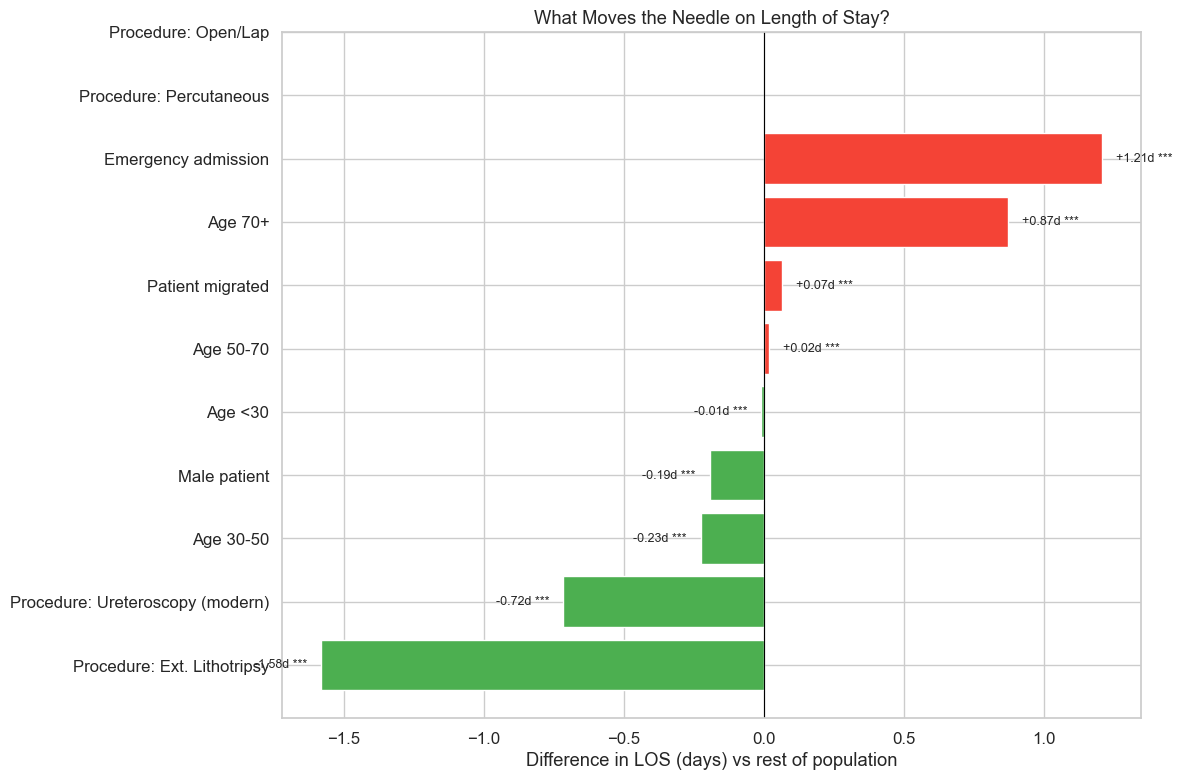

In [8]:
# Visualize factor effects
fig, ax = plt.subplots(figsize=(12, 8))

colors = ["#4CAF50" if d < 0 else "#F44336" for d in factors_df["diff_days"]]
y_pos = range(len(factors_df))
ax.barh(y_pos, factors_df["diff_days"], color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(factors_df["factor"])
ax.set_xlabel("Difference in LOS (days) vs rest of population")
ax.set_title("What Moves the Needle on Length of Stay?")
ax.axvline(0, color="black", linewidth=0.8)

for i, (_, row) in enumerate(factors_df.iterrows()):
    sig = "***" if row["p_value"] < 0.001 else "**" if row["p_value"] < 0.01 else "*" if row["p_value"] < 0.05 else ""
    offset = 0.05 if row["diff_days"] >= 0 else -0.05
    ha = "left" if row["diff_days"] >= 0 else "right"
    ax.text(row["diff_days"] + offset, i, f"{row['diff_days']:+.2f}d {sig}",
            va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / "07_los_factors.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 3: Hospital-Level Deep Dive — Where Are the Worst Performers?

Identify specific hospitals that are costing the system the most.
Compare best vs worst performers on the same procedure mix.

In [9]:
# Hospital-level profile
hospital = kidney.groupby("CNES").agg(
    volume=("DIAG_PRINC", "count"),
    total_cost=("bed_days_cost", "sum"),
    avg_cost=("bed_days_cost", "mean"),
    total_bed_days=("DIAS_PERM", "sum"),
    avg_los=("DIAS_PERM", "mean"),
    median_los=("DIAS_PERM", "median"),
    pct_emergency=("is_emergency", "mean"),
    pct_migrated=("migrated", "mean"),
    mortality=("MORTE", "mean"),
    avg_age=("age", "mean"),
    city=("MUNIC_MOV", "first"),
).reset_index()

# Add procedure mix
for proc, label in PROC_LABELS.items():
    col = f"pct_{label.split()[0].lower()}"
    pct = kidney.groupby("CNES")["PROC_REA"].apply(lambda x: (x == proc).mean())
    hospital = hospital.merge(pct.rename(col).reset_index(), on="CNES", how="left")

# Significant hospitals only (50+ admissions)
h_sig = hospital[hospital["volume"] >= 50].copy()

# Cost efficiency: cost per bed-day
h_sig["cost_per_bed_day"] = h_sig["total_cost"] / h_sig["total_bed_days"]

# "Excess bed-days" = total_bed_days - (volume * system_median_los)
system_median = kidney["DIAS_PERM"].median()
h_sig["excess_bed_days"] = h_sig["total_bed_days"] - (h_sig["volume"] * system_median)
h_sig["excess_cost"] = h_sig["excess_bed_days"] * h_sig["cost_per_bed_day"]

print(f"Hospitals with 50+ admissions: {len(h_sig)}")
print(f"System median LOS: {system_median:.0f} days")
print(f"\nTop 15 hospitals by excess bed-days (most waste):")
top_waste = h_sig.nlargest(15, "excess_bed_days")
print(top_waste[["CNES", "city", "volume", "avg_los", "median_los", "pct_emergency",
                  "excess_bed_days", "total_cost"]].to_string(index=False))

print(f"\nTop 15 hospitals by efficiency (best performers):")
top_efficient = h_sig.nsmallest(15, "avg_los")
print(top_efficient[["CNES", "city", "volume", "avg_los", "median_los", "pct_emergency",
                      "excess_bed_days", "total_cost"]].to_string(index=False))

Hospitals with 50+ admissions: 251
System median LOS: 2 days

Top 15 hospitals by excess bed-days (most waste):
   CNES   city  volume  avg_los  median_los  pct_emergency  excess_bed_days  total_cost
2081695 355220    4005 3.827715         3.0       0.365793           7320.0  3965525.17
2755130 354140    7516 2.883981         2.0       0.792975           6644.0  8144563.00
2688689 355030    2870 4.077700         3.0       0.673519           5963.0  3121281.30
2077477 355030    3850 3.321818         2.0       0.539740           5089.0  4567789.54
2748223 350750    2377 3.975599         3.0       0.871687           4696.0  2112913.20
2077396 354980    6891 2.624293         2.0       0.496590           4302.0  7376620.26
2080680 353060    2766 3.426970         2.0       0.535792           3947.0  2061307.04
2078015 355030    5012 2.660814         2.0       0.330407           3312.0  7006755.05
2077485 355030    2336 3.314212         2.0       0.059932           3070.0  2285571.98
9465464 

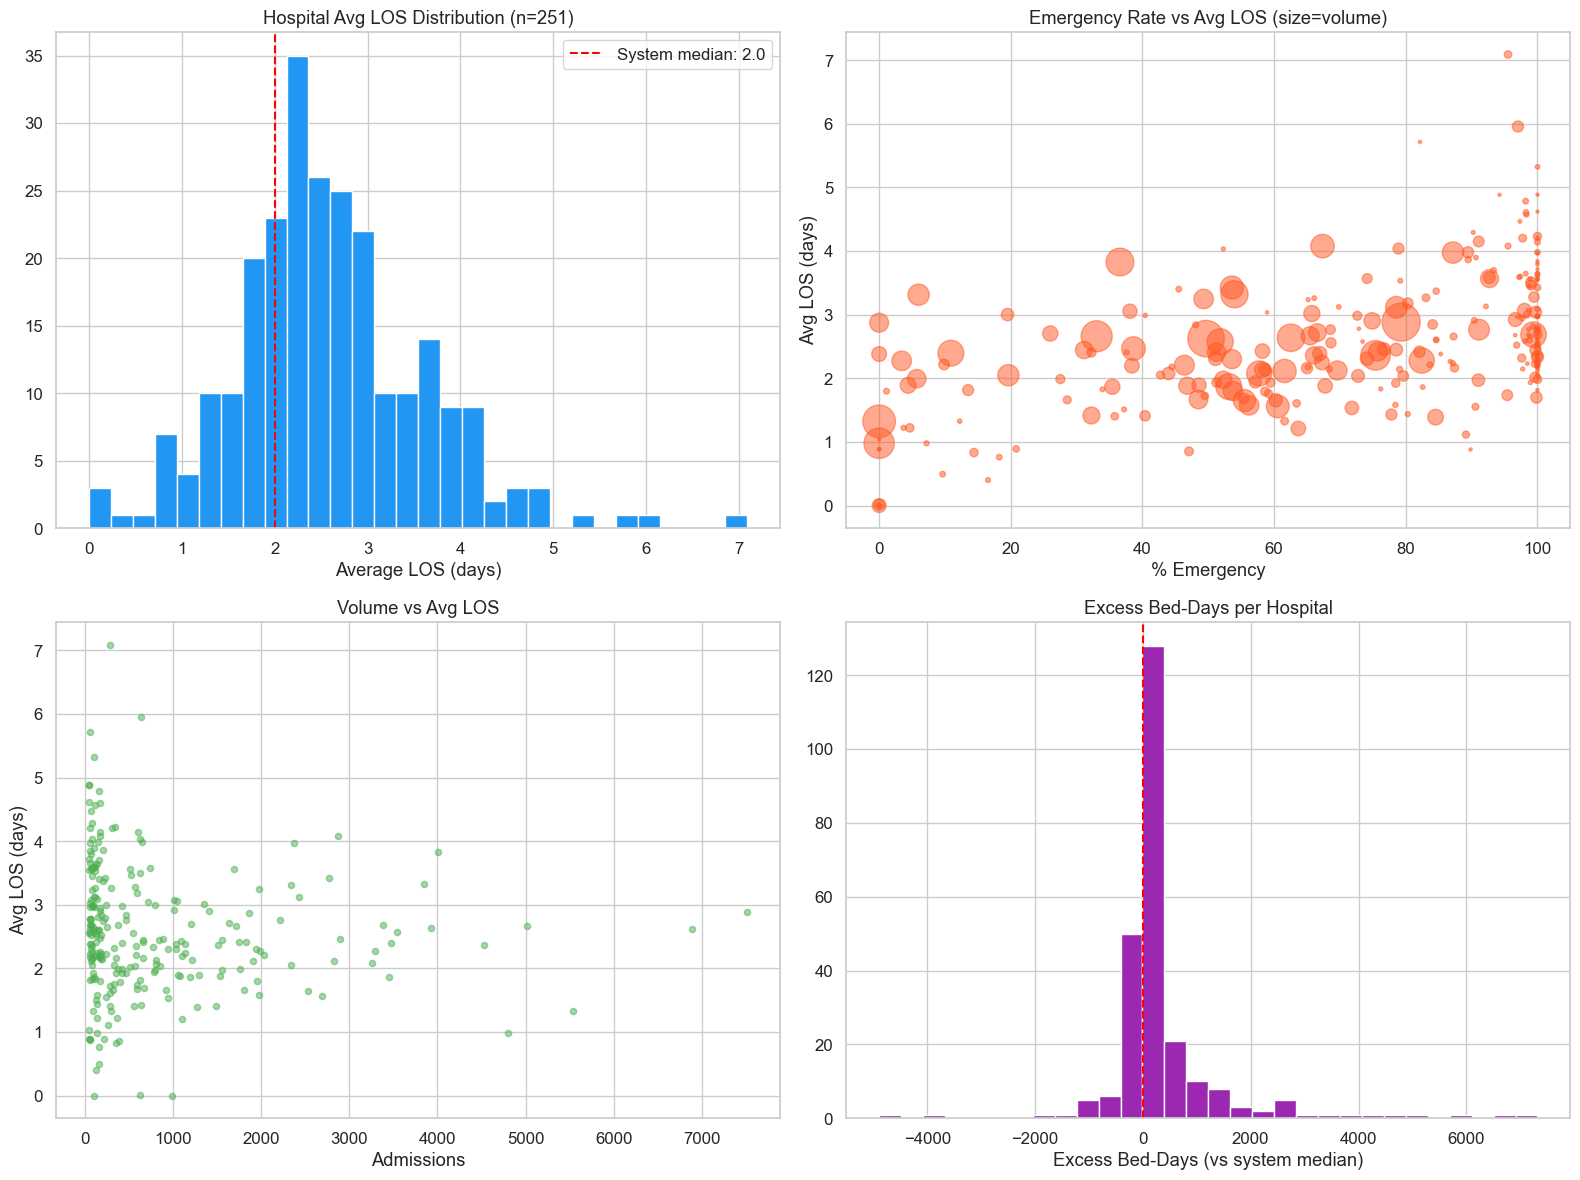


Hospitals above system median: 183 of 251
Total excess bed-days: 117,218
Total excess cost: R$ 33,417,445


In [10]:
# Hospital variation visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Avg LOS distribution
axes[0, 0].hist(h_sig["avg_los"], bins=30, color="#2196F3", edgecolor="white")
axes[0, 0].axvline(system_median, color="red", linestyle="--", label=f"System median: {system_median}")
axes[0, 0].set_title(f"Hospital Avg LOS Distribution (n={len(h_sig)})")
axes[0, 0].set_xlabel("Average LOS (days)")
axes[0, 0].legend()

# ER rate vs LOS
axes[0, 1].scatter(h_sig["pct_emergency"] * 100, h_sig["avg_los"],
                   s=h_sig["volume"] / 10, alpha=0.5, c="#FF5722")
axes[0, 1].set_title("Emergency Rate vs Avg LOS (size=volume)")
axes[0, 1].set_xlabel("% Emergency")
axes[0, 1].set_ylabel("Avg LOS (days)")

# Volume vs LOS
axes[1, 0].scatter(h_sig["volume"], h_sig["avg_los"], alpha=0.5, s=20, c="#4CAF50")
axes[1, 0].set_title("Volume vs Avg LOS")
axes[1, 0].set_xlabel("Admissions")
axes[1, 0].set_ylabel("Avg LOS (days)")

# Excess bed-days distribution
axes[1, 1].hist(h_sig["excess_bed_days"], bins=30, color="#9C27B0", edgecolor="white")
axes[1, 1].axvline(0, color="red", linestyle="--")
axes[1, 1].set_title("Excess Bed-Days per Hospital")
axes[1, 1].set_xlabel("Excess Bed-Days (vs system median)")

plt.tight_layout()
plt.savefig(PLOT_DIR / "07_hospital_variation.png", dpi=150, bbox_inches="tight")
plt.show()

total_excess = h_sig[h_sig["excess_bed_days"] > 0]["excess_bed_days"].sum()
total_excess_cost = h_sig[h_sig["excess_cost"] > 0]["excess_cost"].sum()
n_above = (h_sig["excess_bed_days"] > 0).sum()
print(f"\nHospitals above system median: {n_above} of {len(h_sig)}")
print(f"Total excess bed-days: {total_excess:,.0f}")
print(f"Total excess cost: R$ {total_excess_cost:,.0f}")

## Part 4: Long-Stay Analysis — The Tail Is Where The Waste Lives

Patients staying >7 days are outliers for kidney stones.
Who are they? Where are they? What procedures did they get?

In [11]:
# Long-stay analysis
kidney["stay_group"] = pd.cut(kidney["DIAS_PERM"],
                               bins=[-1, 1, 3, 7, 14, 999],
                               labels=["0-1d", "2-3d", "4-7d", "8-14d", "15+d"])

stay_analysis = kidney.groupby("stay_group", observed=True).agg(
    n_patients=("DIAG_PRINC", "count"),
    total_bed_days=("DIAS_PERM", "sum"),
    total_cost=("bed_days_cost", "sum"),
    pct_emergency=("is_emergency", "mean"),
    avg_age=("age", "mean"),
    mortality=("MORTE", "mean"),
    pct_migrated=("migrated", "mean"),
)

stay_analysis["pct_patients"] = stay_analysis["n_patients"] / total_admissions * 100
stay_analysis["pct_bed_days"] = stay_analysis["total_bed_days"] / total_bed_days * 100
stay_analysis["pct_cost"] = stay_analysis["total_cost"] / total_cost * 100

print("=== Stay Duration Groups ===")
print(stay_analysis[["n_patients", "pct_patients", "pct_bed_days", "pct_cost",
                      "pct_emergency", "avg_age", "mortality"]].round(2).to_string())

# Key finding: what % of patients consume what % of resources?
long_stay = kidney[kidney["DIAS_PERM"] > 7]
print(f"\n=== Long Stays (>7 days) ===")
print(f"Patients: {len(long_stay):,} ({len(long_stay)/total_admissions*100:.1f}%)")
print(f"Bed-days: {long_stay['DIAS_PERM'].sum():,.0f} ({long_stay['DIAS_PERM'].sum()/total_bed_days*100:.1f}%)")
print(f"Cost: R$ {long_stay['bed_days_cost'].sum():,.0f} ({long_stay['bed_days_cost'].sum()/total_cost*100:.1f}%)")

=== Stay Duration Groups ===
            n_patients  pct_patients  pct_bed_days  pct_cost  pct_emergency  avg_age  mortality
stay_group                                                                                     
0-1d             89305         43.25         12.47     37.73           0.43    46.61       0.00
2-3d             79265         38.38         36.32     36.31           0.63    45.61       0.00
4-7d             28600         13.85         27.70     14.88           0.74    46.11       0.00
8-14d             7257          3.51         14.15      6.23           0.79    49.13       0.02
15+d              2073          1.00          9.35      4.85           0.83    53.59       0.09

=== Long Stays (>7 days) ===
Patients: 9,330 (4.5%)
Bed-days: 119,298 (23.5%)
Cost: R$ 20,821,622 (11.1%)


=== Procedure Mix: Short vs Long Stay ===
                       Short stay (<=3d)  Long stay (>7d)
proc_label                                               
Other/Conservative                  80.3             90.1
Ureteroscopy (modern)               18.2              9.3
Ext. Lithotripsy                     1.5              0.6


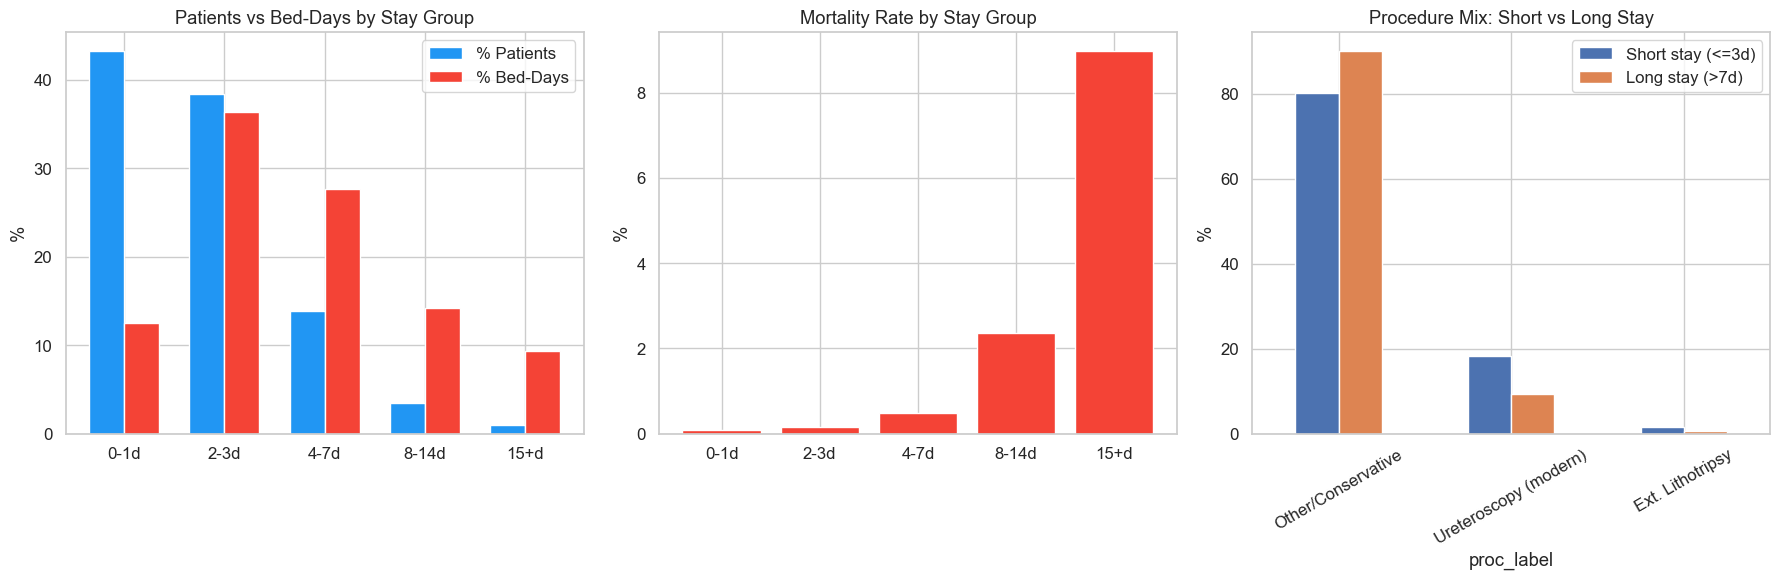

In [12]:
# Long-stay patients: procedure mix vs short-stay
long_proc = kidney[kidney["DIAS_PERM"] > 7]["proc_label"].value_counts(normalize=True) * 100
short_proc = kidney[kidney["DIAS_PERM"] <= 3]["proc_label"].value_counts(normalize=True) * 100

proc_comparison = pd.DataFrame({
    "Short stay (<=3d)": short_proc,
    "Long stay (>7d)": long_proc,
}).fillna(0).round(1)

print("=== Procedure Mix: Short vs Long Stay ===")
print(proc_comparison.to_string())

# Visualize the disproportionate resource consumption
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pareto: patients vs bed-days
categories = stay_analysis.index.tolist()
x = range(len(categories))
width = 0.35
axes[0].bar([i - width/2 for i in x], stay_analysis["pct_patients"], width,
            label="% Patients", color="#2196F3")
axes[0].bar([i + width/2 for i in x], stay_analysis["pct_bed_days"], width,
            label="% Bed-Days", color="#F44336")
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_title("Patients vs Bed-Days by Stay Group")
axes[0].set_ylabel("%")
axes[0].legend()

# Mortality by stay group
axes[1].bar(categories, stay_analysis["mortality"] * 100, color="#F44336")
axes[1].set_title("Mortality Rate by Stay Group")
axes[1].set_ylabel("%")

# Procedure mix for long-stay vs short-stay
proc_comparison.plot(kind="bar", ax=axes[2])
axes[2].set_title("Procedure Mix: Short vs Long Stay")
axes[2].set_ylabel("%")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(PLOT_DIR / "07_long_stay_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 5: Temporal Efficiency — Are Things Getting Better?

Track efficiency metrics over time. Which hospitals improved? Which regressed?

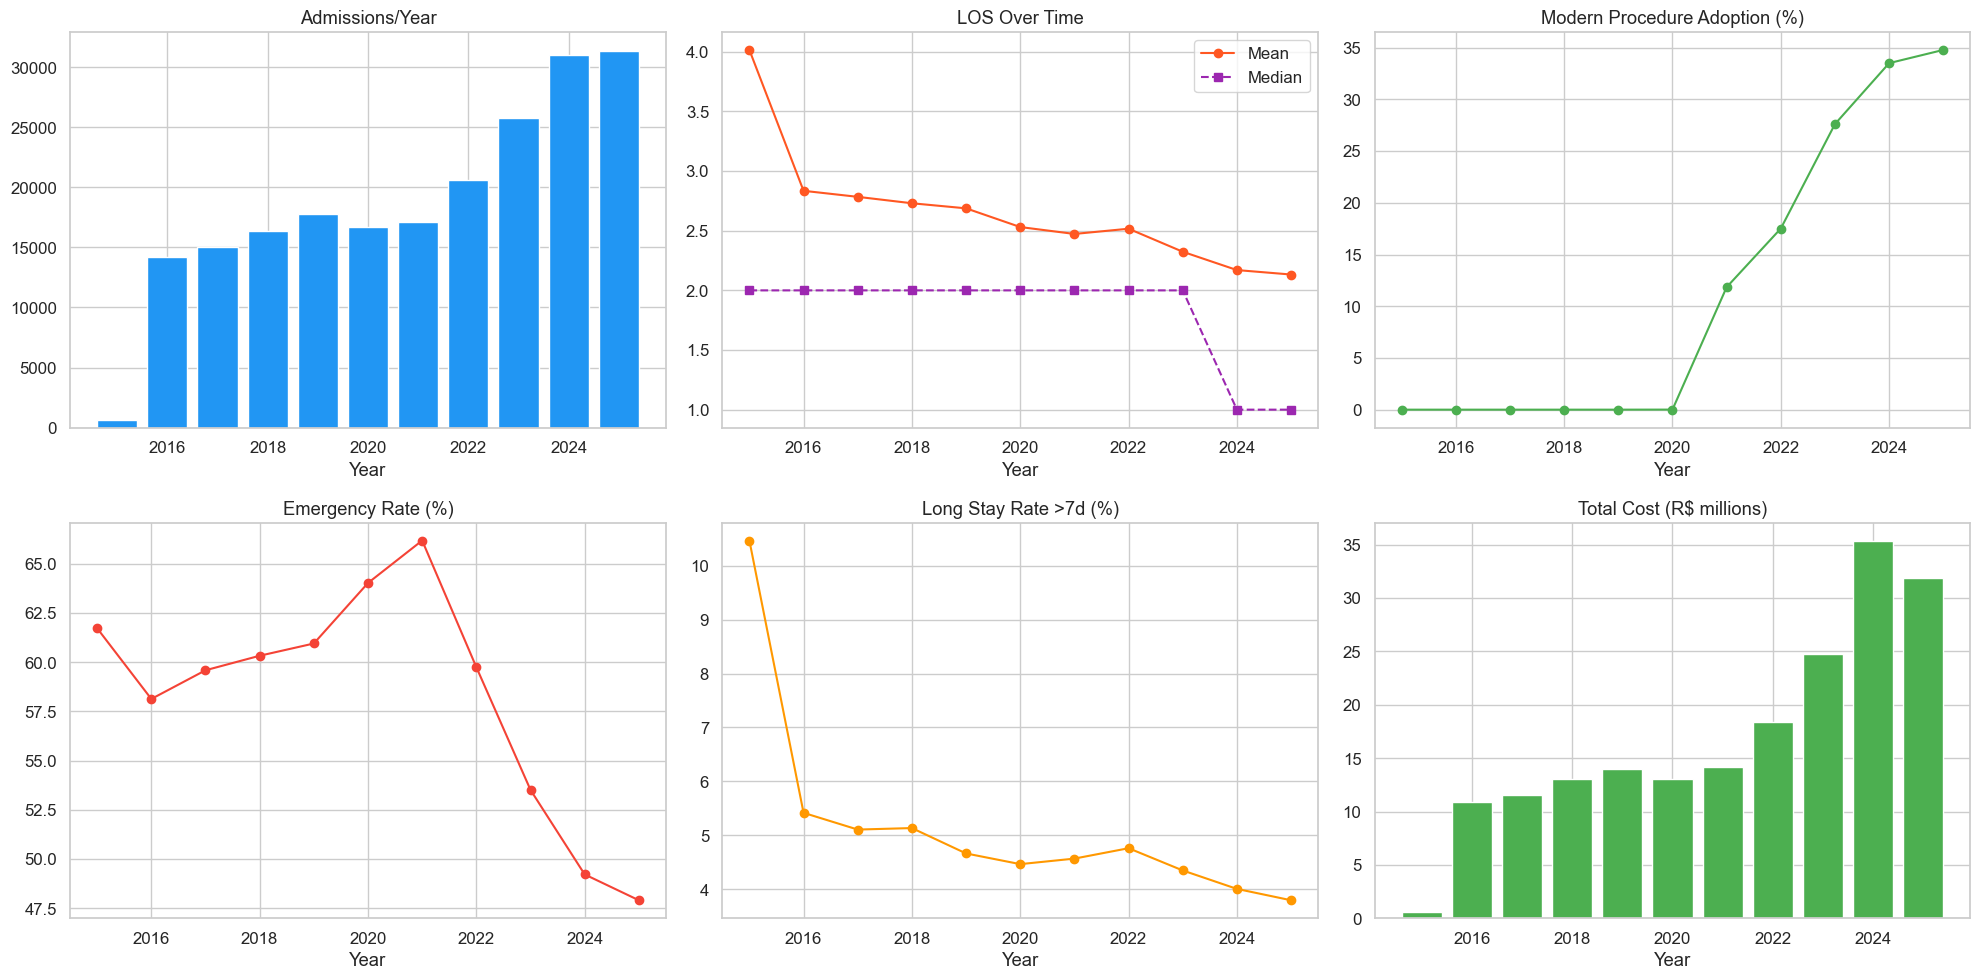

 year  admissions  avg_los  pct_modern_proc  pct_emergency  pct_long_stay  cost_per_bed_day  mortality
 2015         640    4.016            0.000          0.617          0.105           232.252      0.003
 2016       14234    2.835            0.000          0.581          0.054           269.580      0.004
 2017       15002    2.784            0.000          0.596          0.051           276.918      0.004
 2018       16362    2.730            0.000          0.603          0.051           292.424      0.003
 2019       17757    2.688            0.000          0.609          0.047           293.344      0.004
 2020       16664    2.531            0.000          0.640          0.045           310.190      0.004
 2021       17144    2.473            0.118          0.662          0.046           335.042      0.004
 2022       20588    2.517            0.175          0.597          0.048           355.338      0.003
 2023       25762    2.324            0.276          0.535          0.043

In [13]:
# Yearly efficiency trends
yearly = kidney.groupby("year").agg(
    admissions=("DIAG_PRINC", "count"),
    avg_los=("DIAS_PERM", "mean"),
    median_los=("DIAS_PERM", "median"),
    total_cost=("bed_days_cost", "sum"),
    avg_cost=("bed_days_cost", "mean"),
    total_bed_days=("DIAS_PERM", "sum"),
    pct_emergency=("is_emergency", "mean"),
    pct_modern_proc=("proc_label", lambda x: (x == "Ureteroscopy (modern)").mean()),
    pct_long_stay=("DIAS_PERM", lambda x: (x > 7).mean()),
    mortality=("MORTE", "mean"),
).reset_index()

yearly["cost_per_bed_day"] = yearly["total_cost"] / yearly["total_bed_days"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

axes[0, 0].bar(yearly["year"], yearly["admissions"], color="#2196F3")
axes[0, 0].set_title("Admissions/Year")

axes[0, 1].plot(yearly["year"], yearly["avg_los"], "o-", color="#FF5722", label="Mean")
axes[0, 1].plot(yearly["year"], yearly["median_los"], "s--", color="#9C27B0", label="Median")
axes[0, 1].set_title("LOS Over Time")
axes[0, 1].legend()

axes[0, 2].plot(yearly["year"], yearly["pct_modern_proc"] * 100, "o-", color="#4CAF50")
axes[0, 2].set_title("Modern Procedure Adoption (%)")

axes[1, 0].plot(yearly["year"], yearly["pct_emergency"] * 100, "o-", color="#F44336")
axes[1, 0].set_title("Emergency Rate (%)")

axes[1, 1].plot(yearly["year"], yearly["pct_long_stay"] * 100, "o-", color="#FF9800")
axes[1, 1].set_title("Long Stay Rate >7d (%)")

axes[1, 2].bar(yearly["year"], yearly["total_cost"] / 1e6, color="#4CAF50")
axes[1, 2].set_title("Total Cost (R$ millions)")

for ax in axes.flat:
    ax.set_xlabel("Year")

plt.tight_layout()
plt.savefig(PLOT_DIR / "07_temporal_trends.png", dpi=150, bbox_inches="tight")
plt.show()

print(yearly[["year", "admissions", "avg_los", "pct_modern_proc", "pct_emergency",
              "pct_long_stay", "cost_per_bed_day", "mortality"]].round(3).to_string(index=False))

## Part 6: Evidence-Based Bed Savings Estimate

Instead of using a weak ML model for counterfactuals, calculate bed savings from actual data:
1. If above-median hospitals reduced to median LOS
2. If emergency rate reduced at high-ER hospitals
3. If long-stay patients were reduced

In [14]:
# Use most recent 2 years for annualized estimates
recent = kidney[kidney["year"] >= 2024].copy()
if len(recent) == 0:
    recent = kidney[kidney["year"] >= 2023].copy()

recent_years = recent["year"].nunique()
annual_admissions = len(recent) / recent_years
annual_bed_days = recent["DIAS_PERM"].sum() / recent_years
annual_cost = recent["bed_days_cost"].sum() / recent_years

print(f"=== Annualized Baseline (from {recent['year'].min()}-{recent['year'].max()}) ===")
print(f"Annual admissions: {annual_admissions:,.0f}")
print(f"Annual bed-days: {annual_bed_days:,.0f}")
print(f"Annual cost: R$ {annual_cost:,.0f}")

avg_cost_per_bed_day = annual_cost / annual_bed_days
print(f"Cost per bed-day: R$ {avg_cost_per_bed_day:,.0f}")

# Scenario 1: Bring above-median hospitals down to median
recent_hospital = recent.groupby("CNES").agg(
    volume=("DIAG_PRINC", "count"),
    total_bed_days=("DIAS_PERM", "sum"),
    avg_los=("DIAS_PERM", "mean"),
    pct_emergency=("is_emergency", "mean"),
).reset_index()

recent_median_los = recent["DIAS_PERM"].median()
rh_sig = recent_hospital[recent_hospital["volume"] >= 20].copy()
rh_above = rh_sig[rh_sig["avg_los"] > recent_median_los].copy()
rh_above["target_bed_days"] = rh_above["volume"] * recent_median_los
rh_above["saveable_bed_days"] = rh_above["total_bed_days"] - rh_above["target_bed_days"]
rh_above["saveable_bed_days"] = rh_above["saveable_bed_days"].clip(lower=0)

scenario1_bed_days_saved = rh_above["saveable_bed_days"].sum() / recent_years
scenario1_beds_freed = scenario1_bed_days_saved / 365
scenario1_cost_saved = scenario1_bed_days_saved * avg_cost_per_bed_day

print(f"\n=== Scenario 1: Above-median hospitals reduce to median LOS ===")
print(f"Hospitals targeted: {len(rh_above)}")
print(f"Bed-days saved/year: {scenario1_bed_days_saved:,.0f}")
print(f"Beds freed: {scenario1_beds_freed:.1f}")
print(f"Cost saved: R$ {scenario1_cost_saved:,.0f}")

# Scenario 2: Reduce long stays (>7d) by 30%
long_recent = recent[recent["DIAS_PERM"] > 7]
excess_long_bed_days = (long_recent["DIAS_PERM"] - 7).sum()
scenario2_bed_days_saved = excess_long_bed_days * 0.30 / recent_years
scenario2_beds_freed = scenario2_bed_days_saved / 365
scenario2_cost_saved = scenario2_bed_days_saved * avg_cost_per_bed_day

print(f"\n=== Scenario 2: Reduce long stays (>7d) excess by 30% ===")
print(f"Long-stay patients/year: {len(long_recent)/recent_years:,.0f}")
print(f"Bed-days saved/year: {scenario2_bed_days_saved:,.0f}")
print(f"Beds freed: {scenario2_beds_freed:.1f}")
print(f"Cost saved: R$ {scenario2_cost_saved:,.0f}")

# Scenario 3: Convert 20% of emergency admissions to elective
er_recent = recent[recent["is_emergency"] == 1]
el_recent = recent[recent["is_emergency"] == 0]
er_avg_los = er_recent["DIAS_PERM"].mean()
el_avg_los = el_recent["DIAS_PERM"].mean()
los_gap = er_avg_los - el_avg_los
n_converted = len(er_recent) * 0.20
scenario3_bed_days_saved = n_converted * los_gap / recent_years
scenario3_beds_freed = scenario3_bed_days_saved / 365
scenario3_cost_saved = scenario3_bed_days_saved * avg_cost_per_bed_day

print(f"\n=== Scenario 3: Convert 20% of ER admissions to elective ===")
print(f"ER->Elective conversions/year: {n_converted/recent_years:,.0f}")
print(f"LOS gap (ER - Elective): {los_gap:.2f} days")
print(f"Bed-days saved/year: {scenario3_bed_days_saved:,.0f}")
print(f"Beds freed: {scenario3_beds_freed:.1f}")
print(f"Cost saved: R$ {scenario3_cost_saved:,.0f}")

print(f"\n=== Combined Potential (all 3 scenarios) ===")
combined_bed_days = scenario1_bed_days_saved + scenario2_bed_days_saved + scenario3_bed_days_saved
combined_beds = combined_bed_days / 365
combined_cost = scenario1_cost_saved + scenario2_cost_saved + scenario3_cost_saved
print(f"Total bed-days saved/year: {combined_bed_days:,.0f}")
print(f"Total beds freed: {combined_beds:.1f}")
print(f"Total cost saved: R$ {combined_cost:,.0f}")

=== Annualized Baseline (from 2024-2025) ===
Annual admissions: 31,174
Annual bed-days: 67,066
Annual cost: R$ 33,616,276
Cost per bed-day: R$ 501

=== Scenario 1: Above-median hospitals reduce to median LOS ===
Hospitals targeted: 195
Bed-days saved/year: 35,344
Beds freed: 96.8
Cost saved: R$ 17,715,636

=== Scenario 2: Reduce long stays (>7d) excess by 30% ===
Long-stay patients/year: 1,216
Bed-days saved/year: 2,064
Beds freed: 5.7
Cost saved: R$ 1,034,563

=== Scenario 3: Convert 20% of ER admissions to elective ===
ER->Elective conversions/year: 3,027
LOS gap (ER - Elective): 1.32 days
Bed-days saved/year: 4,010
Beds freed: 11.0
Cost saved: R$ 2,010,041

=== Combined Potential (all 3 scenarios) ===
Total bed-days saved/year: 41,418
Total beds freed: 113.5
Total cost saved: R$ 20,760,239


In [15]:
# Save all deep research metrics
deep_metrics = {
    "financial_overview": {
        "total_admissions": int(total_admissions),
        "total_bed_days": int(total_bed_days),
        "total_cost_brl": round(float(total_cost)),
        "avg_cost_per_admission": round(float(total_cost/total_admissions)),
        "avg_cost_per_bed_day": round(float(avg_cost_per_bed_day)),
    },
    "cost_by_procedure": cost_by_proc[["n_admissions", "avg_los", "avg_cost",
                                       "pct_of_total_cost"]].round(2).to_dict(),
    "los_factors": factors_df[["factor", "diff_days", "effect_direction",
                               "group_mean", "n_group"]].to_dict(orient="records"),
    "long_stay_impact": {
        "pct_patients_gt7d": round(float(len(long_stay)/total_admissions*100), 1),
        "pct_bed_days_gt7d": round(float(long_stay["DIAS_PERM"].sum()/total_bed_days*100), 1),
        "pct_cost_gt7d": round(float(long_stay["bed_days_cost"].sum()/total_cost*100), 1),
    },
    "hospital_variation": {
        "n_hospitals_analyzed": len(h_sig),
        "n_above_median": int(n_above),
        "total_excess_bed_days": round(float(total_excess)),
        "total_excess_cost_brl": round(float(total_excess_cost)),
        "los_range": [round(float(h_sig["avg_los"].min()), 1),
                      round(float(h_sig["avg_los"].max()), 1)],
    },
    "bed_savings_scenarios": {
        "baseline_annual_admissions": round(float(annual_admissions)),
        "baseline_annual_bed_days": round(float(annual_bed_days)),
        "baseline_annual_cost": round(float(annual_cost)),
        "scenario1_standardize_hospitals": {
            "bed_days_saved": round(float(scenario1_bed_days_saved)),
            "beds_freed": round(float(scenario1_beds_freed), 1),
            "cost_saved_brl": round(float(scenario1_cost_saved)),
        },
        "scenario2_reduce_long_stays": {
            "bed_days_saved": round(float(scenario2_bed_days_saved)),
            "beds_freed": round(float(scenario2_beds_freed), 1),
            "cost_saved_brl": round(float(scenario2_cost_saved)),
        },
        "scenario3_er_to_elective": {
            "bed_days_saved": round(float(scenario3_bed_days_saved)),
            "beds_freed": round(float(scenario3_beds_freed), 1),
            "cost_saved_brl": round(float(scenario3_cost_saved)),
        },
        "combined": {
            "bed_days_saved": round(float(combined_bed_days)),
            "beds_freed": round(float(combined_beds), 1),
            "cost_saved_brl": round(float(combined_cost)),
        },
    },
}

with open(METRICS_DIR / "deep_research_metrics.json", "w") as f:
    json.dump(deep_metrics, f, indent=2, default=str)

print("Deep research metrics saved.")

Deep research metrics saved.
